# 参数估计与似然

学习目标：区分参数、估计量与估计值，用抽样分布分析偏差、方差和均方误差，推导简单模型的极大似然估计并核对模型假设与边界。

前置知识：随机变量、独立同分布、期望与方差、二项分布与正态分布、抽样分布、对数与求导；Python 函数、数组与基本绘图。

运行环境：Python 3.12，NumPy、SciPy、Matplotlib；使用自制小型数据和固定种子的本地模拟，所有数值均无量纲。

环境准备：见 [数学基础环境与运行说明](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 一个比例，三个不同对象

某项试验每次只记录成功 1 或失败 0。先用六次自制记录 $x=(1,0,1,1,0,1)$，以成功次数除以总次数估计成功概率。计算得到 $4/6$，但它不意味着真实成功概率恰好就是这个数。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

observed = np.array([1, 0, 1, 1, 0, 1])
observed_n = observed.size
observed_k = observed.sum()
p_estimate = observed.mean()
print("样本量、成功次数：", observed_n, observed_k)  # 预期为 6 4。
print("样本比例：", p_estimate)  # 预期约为 0.666667。
# 这是当前六次记录给出的估计值；更换样本会得到不同结果。

样本量、成功次数： 6 4
样本比例： 0.6666666666666666


假设随机变量 $X_1,\ldots,X_n$ 独立同分布于 Bernoulli$(p)$，$n\geq1$ 为整数，$p\in[0,1]$。$X_i$ 表示尚未观察的第 $i$ 次结果，$x_i$ 表示它的实际取值；本章按频率学派观点把真实参数视为固定但未知。

| 原文名称 | 中文名称／含义 | 当前例子 |
| --- | --- | --- |
| Parameter | 参数，描述总体分布的固定量 | 成功概率 $p$ |
| Estimator | 估计量，样本的函数，抽样前是随机变量 | $\widehat p_n=\overline X=\frac1n\sum_{i=1}^nX_i$ |
| Estimate | 估计值，把已观察数据代入估计量后的数值 | $\widehat p_n(x)=4/6$ |

点估计（point estimation）用一个数或参数向量作为估计结果，不直接给出不确定性的区间。一般写作 $\widehat\theta_n=T(X_1,\ldots,X_n)$，其中 $T$ 是不含未知参数的计算规则，$\theta\in\Theta$ 是待估参数，$\Theta$ 称为参数空间。选择分布族和参数空间都是模型假设的一部分。

In [2]:
another_sample = np.array([0, 0, 1, 0, 1, 0])
print("同一计算规则作用于第一份数据：", observed.mean())  # 预期约为 0.666667。
print("同一计算规则作用于第二份数据：", another_sample.mean())  # 预期约为 0.333333。
# 两个估计值不同；估计量的规则仍然是“求样本均值”。

同一计算规则作用于第一份数据： 0.6666666666666666
同一计算规则作用于第二份数据： 0.3333333333333333


## 2 抽样分布描述估计量怎样变化

固定真实 $p$ 和样本量 $n$，重复进行整组抽样，$\widehat p_n$ 的分布就是它的抽样分布。它不同于单个 $X_i$ 的分布，也不是固定数据之后关于 $p$ 的分布。

令成功总数 $K=\sum_{i=1}^nX_i$。由于 $K\sim\operatorname{Binomial}(n,p)$，对 $k=0,1,\ldots,n$，

$$P_p\left(\widehat p_n=\frac{k}{n}\right)=\binom nk p^k(1-p)^{n-k}.$$

下标 $p$ 表示概率按该真实参数计算。下面取 $n=4,p=0.3$，枚举全部五个可能的估计值；这是精确分布计算，不是模拟频数。

In [3]:
n = 4
true_p = 0.3
counts = np.arange(n + 1)
possible_estimates = counts / n
sampling_probabilities = stats.binom.pmf(counts, n, true_p)
for estimate, probability in zip(possible_estimates, sampling_probabilities):
    print(f"估计值={estimate:.2f}，概率={probability:.4f}")  # 五个估计值的概率依次为 0.2401、0.4116、0.2646、0.0756、0.0081。
print("总概率：", sampling_probabilities.sum())  # 预期约为 1。
# 总概率约为 1；单个 X_i 只有 0/1 两种结果，样本比例有五种可能。

估计值=0.00，概率=0.2401
估计值=0.25，概率=0.4116
估计值=0.50，概率=0.2646
估计值=0.75，概率=0.0756
估计值=1.00，概率=0.0081
总概率： 1.0000000000000002


下图比较 $n=4$ 和 $n=40$ 的精确抽样分布，真实参数均为 $0.3$。柱高是各个离散估计值的概率质量，不是概率密度；橙线标记固定的真实参数。

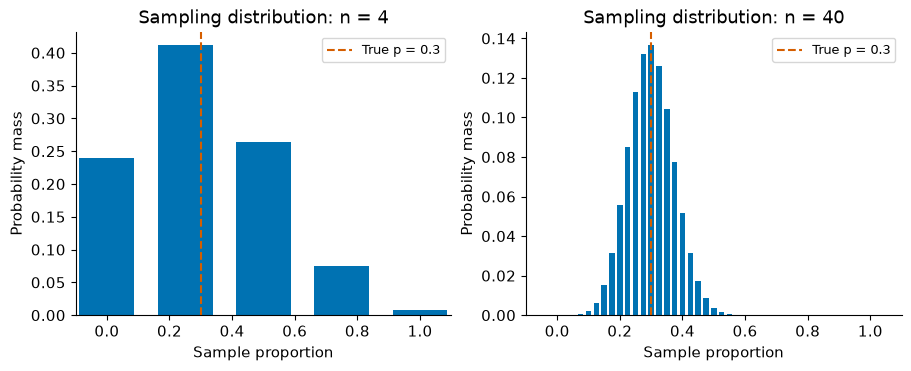

In [4]:
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)
blue, orange, green = "#0072B2", "#D55E00", "#009E73"
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), layout="constrained")
# 遍历所有可能成功次数，除以 n 后变成样本比例的取值。
for ax, sample_size in zip(axes, [4, 40]):
    possible_counts = np.arange(sample_size + 1)
    probabilities = stats.binom.pmf(possible_counts, sample_size, true_p)
    # 柱高仍是对应计数的概率质量，柱宽只随离散取值间距调整。
    ax.bar(
        possible_counts / sample_size,
        probabilities,
        width=0.7 / sample_size,
        color=blue,
    )
    ax.axvline(true_p, color=orange, linestyle="--", label="True p = 0.3")
    ax.set(
        xlim=(-0.1, 1.1),
        xlabel="Sample proportion",
        ylabel="Probability mass",
        title=f"Sampling distribution: n = {sample_size}",
    )
    ax.legend(fontsize=9)
plt.show()
# 横轴是估计量可能取到的值；增加 n 后，概率质量更集中在真实参数附近。

## 3 偏差、方差与均方误差

以下先讨论标量参数，并假设估计量有有限二阶矩。偏差（bias）是 $\operatorname{Bias}_\theta(\widehat\theta)=E_\theta[\widehat\theta]-\theta$。若对参数空间中的每个 $\theta$ 都等于零，则称估计量无偏；无偏不要求某一次估计恰好等于真值。

估计量方差 $\operatorname{Var}_\theta(\widehat\theta)=E_\theta[(\widehat\theta-E_\theta\widehat\theta)^2]$ 衡量重复抽样时的波动。其平方根称为标准误（standard error），不是单个观测值的标准差。

对样本比例，期望线性性给出 $E_p\widehat p_n=p$；独立性给出 $\operatorname{Var}_p(\widehat p_n)=n^{-2}\sum_{i=1}^n p(1-p)=p(1-p)/n$。下面沿用五点抽样分布计算这两个量。

In [5]:
expected_estimate = np.sum(possible_estimates * sampling_probabilities)
estimator_variance = np.sum(
    (possible_estimates - expected_estimate) ** 2 * sampling_probabilities
)
print("期望与偏差：", expected_estimate, expected_estimate - true_p)  # 预期期望接近 0.3、偏差接近 0；本次偏差约 5.6e-17。
print("估计量方差与公式：", estimator_variance, true_p * (1 - true_p) / n)  # 预期约为 0.0525 0.0525。
print("估计量标准误：", np.sqrt(estimator_variance))  # 预期约为 0.229129。
print("单个观测值标准差：", np.sqrt(true_p * (1 - true_p)))  # 预期约为 0.458258。
# 偏差约为 0，但方差不为 0；标准误比单个观测值标准差小 sqrt(n) 倍。

期望与偏差： 0.30000000000000004 5.551115123125783e-17
估计量方差与公式： 0.052500000000000005 0.0525
估计量标准误： 0.22912878474779202
单个观测值标准差： 0.458257569495584


均方误差（mean squared error，MSE）把估计值到真值的平方距离再对抽样取期望：

$$\operatorname{MSE}_\theta(\widehat\theta)=E_\theta[(\widehat\theta-\theta)^2]
=\operatorname{Var}_\theta(\widehat\theta)+\operatorname{Bias}_\theta(\widehat\theta)^2.$$

推导时令 $m=E_\theta\widehat\theta$，将 $\widehat\theta-\theta=(\widehat\theta-m)+(m-\theta)$ 展开平方。交叉项的期望是 $2(m-\theta)E_\theta(\widehat\theta-m)=0$，便得到分解式。这里的 MSE 衡量参数估计误差，与单个数据集上的拟合残差平方平均不是同一个对象。

In [6]:
exact_mse = np.sum((possible_estimates - true_p) ** 2 * sampling_probabilities)
decomposed_mse = estimator_variance + (expected_estimate - true_p) ** 2
print("直接计算 MSE：", exact_mse)  # 预期约为 0.0525。
print("方差加偏差平方：", decomposed_mse)  # 预期约为 0.0525。
print("两种计算的差：", exact_mse - decomposed_mse)  # 预期接近 0；本次计算为 0。
# 当前无偏估计量的 MSE 等于方差；不是每个估计量都具有这个等式。

直接计算 MSE： 0.052500000000000005
方差加偏差平方： 0.052500000000000005
两种计算的差： 0.0


## 4 有偏估计也可能有较小 MSE

构造另一条计算规则 $\widetilde p_n=(K+1)/(n+2)$。它也可写成 $\frac{n}{n+2}\widehat p_n+\frac{2}{n+2}\cdot\frac12$，因此把样本比例向 $1/2$ 收缩；这里仅把它作为比较用的估计量。

由 $E_pK=np$、$\operatorname{Var}_pK=np(1-p)$ 可得

$$\operatorname{Bias}_p(\widetilde p_n)=\frac{1-2p}{n+2},\qquad
\operatorname{Var}_p(\widetilde p_n)=\frac{np(1-p)}{(n+2)^2}.$$

它通常有偏，却减少了方差。是否降低 MSE，取决于 $p$ 和 $n$，不能只看其中一个分量。

In [7]:
shrunk_estimates = (counts + 1) / (n + 2)
for label, estimates in [
    ("样本比例", possible_estimates),
    ("向 1/2 收缩", shrunk_estimates),
]:
    average = np.sum(estimates * sampling_probabilities)
    bias = average - true_p
    variance = np.sum((estimates - average) ** 2 * sampling_probabilities)
    mse = np.sum((estimates - true_p) ** 2 * sampling_probabilities)
    # 样本比例的偏差为 0、MSE 为 0.0525；收缩规则偏差约 0.066667，但 MSE 约 0.027778。
    print(f"{label}：偏差={bias:.6f}，方差={variance:.6f}，MSE={mse:.6f}")
# n=4、p=0.3 时，收缩增加偏差，却降低总 MSE。

样本比例：偏差=0.000000，方差=0.052500，MSE=0.052500
向 1/2 收缩：偏差=0.066667，方差=0.023333，MSE=0.027778


把真实 $p$ 在整个 $[0,1]$ 上改变，仍固定 $n=4$。图中两条曲线直接来自刚才的解析公式，表示每个可能真值下的 MSE。参数接近边界时，向 $1/2$ 收缩造成的偏差会很明显。

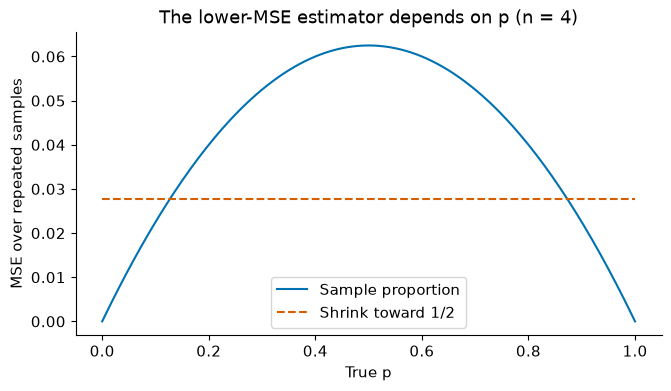

In [8]:
p_grid = np.linspace(0.0, 1.0, 201)
raw_mse = p_grid * (1 - p_grid) / n
shrink_mse = (n * p_grid * (1 - p_grid) + (1 - 2 * p_grid) ** 2) / (n + 2) ** 2
fig, ax = plt.subplots(figsize=(6.6, 3.8), layout="constrained")
ax.plot(p_grid, raw_mse, color=blue, label="Sample proportion")
ax.plot(p_grid, shrink_mse, "--", color=orange, label="Shrink toward 1/2")
ax.set(
    xlabel="True p",
    ylabel="MSE over repeated samples",
    title="The lower-MSE estimator depends on p (n = 4)",
)
ax.legend()
plt.show()
# 不能用 p=0.3 的比较断言收缩规则处处更好；边界处样本比例反而没有误差。

## 5 一致性关注样本量增长

估计量序列 $\widehat\theta_n$ 一致（consistent），指对每个真实 $\theta$ 及任意误差阈值 $\varepsilon>0$，

$$P_\theta(|\widehat\theta_n-\theta|>\varepsilon)\longrightarrow0\quad(n\to\infty).$$

它描述依概率收敛，不要求每增加一次观测，当前误差都变小。若 MSE 趋于零，就能由 $P_\theta(|\widehat\theta_n-\theta|>\varepsilon)\leq\operatorname{MSE}_\theta(\widehat\theta_n)/\varepsilon^2$ 推出一致性。

样本比例的 MSE 为 $p(1-p)/n\to0$，因此一致。收缩估计量的偏差平方和方差也都趋于零，所以即使有限样本时有偏，它仍然一致。反过来，只用第一个观测 $T_n=X_1$ 虽然无偏，却没有随着 $n$ 改善；当 $p=0.3,\varepsilon=0.2$ 时，它的误差超过阈值的概率始终为 1。

In [9]:
error_threshold = 0.2
for sample_size in [4, 16, 64, 256]:
    mse = true_p * (1 - true_p) / sample_size
    probability_bound = min(1.0, mse / error_threshold**2)
    # n 每变为四倍，MSE 变为 1/4；从 0.0525 降至约 0.000820。
    print(
        f"n={sample_size:3d}，样本比例 MSE={mse:.6f}，超阈值概率上界={probability_bound:.6f}"
    )
first_only_errors = np.abs(np.array([0.0, 1.0]) - true_p)
print("只用 X1 时的两种绝对误差：", first_only_errors)  # 预期约为 [0.3 0.7]。
# 上界随 n 下降；X1 无论抽样多少次，可能的误差仍是 0.3 和 0.7。

n=  4，样本比例 MSE=0.052500，超阈值概率上界=1.000000
n= 16，样本比例 MSE=0.013125，超阈值概率上界=0.328125
n= 64，样本比例 MSE=0.003281，超阈值概率上界=0.082031
n=256，样本比例 MSE=0.000820，超阈值概率上界=0.020508
只用 X1 时的两种绝对误差： [0.3 0.7]


## 6 固定数据以后，再看似然

似然（likelihood）使用同一个统计模型，但固定已观察数据，比较不同参数。若联合概率质量或密度记为 $f_\theta(x_1,\ldots,x_n)$，定义

$$L(\theta;x)=f_\theta(x_1,\ldots,x_n).$$

独立同分布条件下，它可以写成 $L(\theta;x)=\prod_{i=1}^n f_\theta(x_i)$；$\prod$ 表示把 $i=1$ 到 $n$ 的各项相乘。若观测相依，就不能直接用边缘分布的乘积替代联合分布。

以有顺序的记录 $x=(1,0,1)$ 为例，$L(p;x)=p^2(1-p)$。这是指定序列的概率；若只记录“3 次里成功 2 次”，相应二项概率会多一个组合系数 $\binom32$。该系数不依赖 $p$，不会改变最大值出现的位置。

In [10]:
short_data = np.array([1, 0, 1])
candidate_probabilities = np.array([0.2, 0.5, 0.8])
for candidate_p in candidate_probabilities:
    sequence_likelihood = stats.bernoulli.pmf(short_data, candidate_p).prod()
    count_likelihood = stats.binom.pmf(2, 3, candidate_p)
    # 三行的序列似然为 0.032、0.125、0.128；只看总数时各乘以 3。
    print(
        f"p={candidate_p:.1f}，指定序列似然={sequence_likelihood:.4f}，只看总数={count_likelihood:.4f}"
    )
# 两种记录方式对应不同事件，但这里两者之比恒为 3。

p=0.2，指定序列似然=0.0320，只看总数=0.0960
p=0.5，指定序列似然=0.1250，只看总数=0.3750
p=0.8，指定序列似然=0.1280，只看总数=0.3840


概率质量或密度的归一化是针对数据空间，不是针对参数空间。当前数据固定后，$\int_0^1p^2(1-p)\,dp=1/3-1/4=1/12$，因此这条似然曲线并不是 $p$ 的概率密度。似然也不是“给定数据后参数的概率”；要讨论参数的后验分布，还需要先验和贝叶斯建模。

对连续观测，似然使用密度值。密度可以大于 1，单点事件的概率却仍为 0，不能把密度值读成“观察到这个数的概率”。

In [11]:
print("对参数积分的解析值：", 1 / 3 - 1 / 4)  # 预期约为 0.0833333。
print("N(0, 0.1²) 在零点的密度：", stats.norm.pdf(0.0, loc=0.0, scale=0.1))  # 预期约为 3.98942。
# 第一项不是 1；第二项大于 1，都不违反概率规则。
# SciPy 的 scale 填标准差 0.1，不是方差 0.01。

对参数积分的解析值： 0.08333333333333331
N(0, 0.1²) 在零点的密度： 3.989422804014327


## 7 对数似然把乘积变为求和

对 $L(\theta;x)>0$ 的候选参数，定义自然对数似然 $\ell(\theta;x)=\log L(\theta;x)$。对数严格递增，所以最大化似然与最大化对数似然的位置相同。独立模型下

$$\ell(\theta;x)=\sum_{i=1}^n\log f_\theta(x_i).$$

零似然对应扩展值 $-\infty$，用来排除无法解释数据的参数。离散模型用 logpmf，连续模型用 logpdf；直接使用这些方法可避免先算极小乘积再取对数。

In [12]:
candidate_p = 0.6
likelihood = stats.bernoulli.pmf(observed, candidate_p).prod()
log_likelihood = stats.bernoulli.logpmf(observed, candidate_p).sum()
print("似然、对数似然：", likelihood, log_likelihood)  # 预期约为 0.020736 -3.87588。
print("先求乘积再取对数的差：", np.log(likelihood) - log_likelihood)  # 本次数值约为 4.4e-16。
print("混合 0/1 样本在 p=1 时的对数似然：", stats.bernoulli.logpmf(observed, 1.0).sum())  # 预期为 -inf。
# 当前短样本的两种算法一致；p=1 不允许出现失败，故返回 -inf。

似然、对数似然： 0.020736000000000004 -3.875883958812273
先求乘积再取对数的差： 4.440892098500626e-16
混合 0/1 样本在 p=1 时的对数似然： -inf


长样本中，相乘的数都不为零，最终乘积仍可能小到无法用浮点数表示。下面仅用 2000 项展示下溢；这不是统计模型把该事件判为不可能。

In [13]:
long_data = np.tile([0, 1], 1000)
direct_product = stats.bernoulli.pmf(long_data, 0.5).prod()
stable_log_likelihood = stats.bernoulli.logpmf(long_data, 0.5).sum()
print("直接乘积：", direct_product)  # 预期为 0。
print("直接求和的对数似然：", stable_log_likelihood)  # 预期约为 -1386.29。
print("与 2000 log(0.5) 的差：", stable_log_likelihood - 2000 * np.log(0.5))  # 本次数值约为 -2.3e-13。
# 乘积下溢为 0，而对数似然约为 -1386.29，仍是有限值。

直接乘积： 0.0
直接求和的对数似然： -1386.2943611198907
与 2000 log(0.5) 的差： -2.2737367544323206e-13


## 8 极大似然要同时检查驻点和边界

极大似然估计（maximum likelihood estimation，MLE，也称最大似然估计）在给定参数空间内寻找

$$\widehat\theta_{\mathrm{MLE}}(x)\in\operatorname*{arg\,max}_{\theta\in\Theta}L(\theta;x).$$

arg max 返回达到最大值的参数，而不是最大似然值；解可能不唯一，也可能不存在。导数为零只是内点候选条件，还需检查是否达到全局最大及参数边界。

Bernoulli 样本中令 $k=\sum_{i=1}^nx_i$。当 $0<k<n$、$0<p<1$ 时，

$$\ell(p)=k\log p+(n-k)\log(1-p),\quad
\ell'(p)=\frac{k}{p}-\frac{n-k}{1-p}.$$

令导数为零可得 $k(1-p)=(n-k)p$，即 $\widehat p=k/n$。又因 $\ell''(p)=-k/p^2-(n-k)/(1-p)^2<0$，这是唯一内点最大值；两端似然为零，因此也是 $[0,1]$ 上的全局最大值。

In [14]:
p_mle = observed_k / observed_n
score = observed_k / p_mle - (observed_n - observed_k) / (1 - p_mle)
curvature = -observed_k / p_mle**2 - (observed_n - observed_k) / (1 - p_mle) ** 2
print("MLE、导数、二阶导数：", p_mle, score, curvature)  # MLE 为 2/3，二阶导数约 -27；一阶导数应接近 0，本次约 8.9e-16。
for candidate_p in [0.4, p_mle, 0.9]:
    # 候选 p=0.4、2/3、0.9 的对数似然约 -4.6868、-3.8191、-5.0266，中间最大。
    print(
        f"p={candidate_p:.6f}，对数似然={stats.bernoulli.logpmf(observed, candidate_p).sum():.6f}"
    )
# 解析候选值的导数约为 0，二阶导数为负；比较采样点只是辅助核对。

MLE、导数、二阶导数： 0.6666666666666666 8.881784197001252e-16 -26.999999999999996
p=0.400000，对数似然=-4.686814
p=0.666667，对数似然=-3.819085
p=0.900000，对数似然=-5.026612


若全成功，$L(p)=p^n$ 在 $[0,1]$ 上的最大值位于边界 $p=1$；若全失败，最大值位于 $p=0$。所以在闭参数空间 $[0,1]$ 上，$\widehat p=k/n$ 覆盖这两种情况。

若模型明确规定 $\Theta=(0,1)$，全成功样本的似然只能在 $p\to1$ 时逼近 1，没有任何允许的参数能达到它，因此不存在 MLE。边界估计为 1 也不证明现实过程永远不会失败，只是当前模型和这份样本的优化结果。

In [15]:
all_successes = np.ones(6, dtype=int)
all_failures = np.zeros(6, dtype=int)
print("闭参数空间的两种边界 MLE：", all_successes.mean(), all_failures.mean())  # 预期为 1 0。
for candidate_p in [0.9, 0.99, 0.999, 1.0]:
    value = stats.bernoulli.pmf(all_successes, candidate_p).prod()
    # p 从 0.9 靠近 1 时似然增大；p=1 的似然为 1，但不属于开区间。
    print(f"p={candidate_p:.3f}，似然={value:.6f}，属于开区间={0 < candidate_p < 1}")
# 开区间里的值越来越接近 1，但达到最大值的位置被参数空间排除了。

闭参数空间的两种边界 MLE： 1.0 0.0
p=0.900，似然=0.531441，属于开区间=True
p=0.990，似然=0.941480，属于开区间=True
p=0.999，似然=0.994015，属于开区间=True
p=1.000，似然=1.000000，属于开区间=False


下图固定样本量为 6，分别画全失败、成功 4 次和全成功的似然。为了比较形状，每条曲线除以各自的最大值；纵轴是相对似然，不是概率分布。黑点标记闭参数空间上的 MLE。

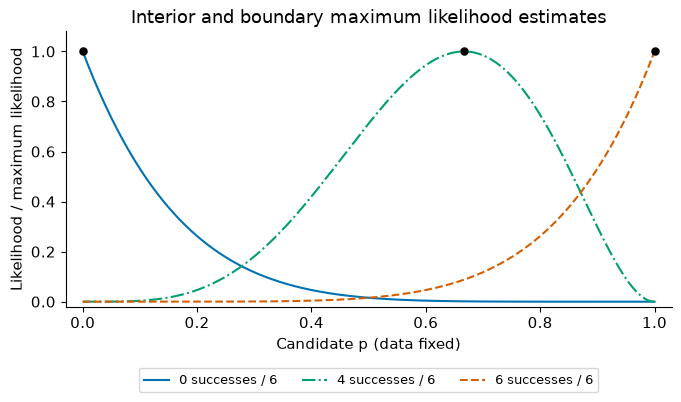

In [16]:
likelihood_grid = np.linspace(0.0, 1.0, 601)
fig, ax = plt.subplots(figsize=(6.7, 3.9), layout="constrained")
# 固定三份数据集，分别在同一参数网格上计算整批观测的似然。
for data, color, style, label in [
    (all_failures, blue, "-", "0 successes / 6"),
    (observed, green, "-.", "4 successes / 6"),
    (all_successes, orange, "--", "6 successes / 6"),
]:
    # data[:, None] 广播成“观测 × 候选参数”，沿观测轴累加对数概率。
    log_values = stats.bernoulli.logpmf(data[:, None], likelihood_grid).sum(axis=0)
    maximum_log = stats.bernoulli.logpmf(data, data.mean()).sum()
    # 减去各自最大对数似然后再指数化，让三条曲线都以最大值 1 比较。
    relative_likelihood = np.exp(log_values - maximum_log)
    ax.plot(likelihood_grid, relative_likelihood, style, color=color, label=label)
    ax.scatter([data.mean()], [1.0], color="black", s=26, zorder=3)
ax.set(
    xlim=(-0.03, 1.03),
    ylim=(-0.02, 1.08),
    xlabel="Candidate p (data fixed)",
    ylabel="Likelihood / maximum likelihood",
    title="Interior and boundary maximum likelihood estimates",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=9)
# 预期混合样本曲线在 p=2/3 附近最高；全成功与全失败分别在 1、0 达到最大。
plt.show()
# 参数在横轴上变化，数据固定；这与抽样分布图的含义不同。

## 9 正态模型的均值与方差估计

设 $X_i$ 独立同分布于 $N(\mu,v)$，其中均值 $\mu\in\mathbb R$，方差 $v=\sigma^2>0$，参数空间为 $\mathbb R\times(0,\infty)$。对 $n$ 个实数观测，对数似然是

$$\ell(\mu,v)=-\frac n2\log(2\pi v)-\frac{1}{2v}\sum_{i=1}^n(x_i-\mu)^2.$$

令 $\overline x=\frac1n\sum_i x_i$、$S=\sum_i(x_i-\overline x)^2$，其中求和均从 $1$ 到 $n$。恒等式 $\sum_i(x_i-\mu)^2=S+n(\mu-\overline x)^2$ 说明：固定任何 $v>0$，都在 $\mu=\overline x$ 时最大。

代入后对 $v$ 求导，得到 $\partial\ell(\overline x,v)/\partial v=(S-nv)/(2v^2)$。当 $S>0$ 时，导数在 $v=S/n$ 左正右负，因此全局最大值为 $\widehat\mu=\overline x$、$\widehat v=S/n$。

In [17]:
measurements = np.array([1.1, 1.5, 1.8, 2.0])
normal_n = measurements.size
mu_mle = measurements.mean()
centered_sum = np.sum((measurements - mu_mle) ** 2)
variance_mle = centered_sum / normal_n
print("均值、离差平方和、方差 MLE：", mu_mle, centered_sum, variance_mle)  # 预期约为 1.6 0.46 0.115。
# 预期三个差值都接近 0；本次最大绝对差约 1.1e-16。
print(
    "与手算 (1.6, 0.46, 0.115) 的差：",
    np.array([mu_mle, centered_sum, variance_mle]) - [1.6, 0.46, 0.115],
)
for candidate_mu, candidate_variance in [
    (mu_mle, variance_mle),
    (1.4, variance_mle),
    (mu_mle, 0.3),
]:
    value = stats.norm.logpdf(
        measurements, loc=candidate_mu, scale=np.sqrt(candidate_variance)
    ).sum()
    # 三组对数似然约 -1.35011、-2.04576、-2.03448，MLE 候选最大。
    print(f"μ={candidate_mu:.3f}，v={candidate_variance:.3f}，对数似然={value:.6f}")
# 参数中的 v 是方差；logpdf 的 scale 仍须传 sqrt(v)。

均值、离差平方和、方差 MLE： 1.6 0.4599999999999999 0.11499999999999998
与手算 (1.6, 0.46, 0.115) 的差： [ 0.00000000e+00 -1.11022302e-16 -2.77555756e-17]
μ=1.600，v=0.115，对数似然=-1.350108
μ=1.400，v=0.115，对数似然=-2.045760
μ=1.600，v=0.300，对数似然=-2.034475


这里 $S>0$ 的条件不能省略。若所有观测相同，在 $\mu=\overline x$ 时 $S=0$，对数似然变成 $-\frac n2\log(2\pi v)$，当 $v\to0^+$ 时无上界。方差 0 又不在当前正态模型的参数空间内，所以这种数据没有有限的 MLE；不能直接把计算出来的零方差当作有效参数。

In [18]:
identical_data = np.full(4, 1.6)
for candidate_variance in [0.1, 0.01, 0.001]:
    value = stats.norm.logpdf(
        identical_data, loc=1.6, scale=np.sqrt(candidate_variance)
    ).sum()
    print(f"v={candidate_variance:.3f}，对数似然={value:.6f}")  # v 依次减至 0.1、0.01、0.001，对数似然约 0.9294、5.5346、10.1398。
# 方差越接近零，似然还可继续提高；这些正方差候选值都不是最大值点。

v=0.100，对数似然=0.929416
v=0.010，对数似然=5.534586
v=0.001，对数似然=10.139756


MLE 不保证有限样本无偏。设真实方差为 $v$，对独立同分布且方差有限的样本，利用

$$\sum_{i=1}^n(X_i-\overline X)^2
=\sum_{i=1}^n(X_i-\mu)^2-n(\overline X-\mu)^2$$

取期望，右侧为 $nv-n(v/n)=(n-1)v$。所以 $E\widehat v=(n-1)v/n$，偏差为 $-v/n$。当 $n\geq2$ 时，改除以 $n-1$ 得到无偏方差估计量；它一般不是当前正态模型的方差 MLE。

NumPy 的 var 默认分母为 $n$，设置 ddof=1 后分母为 $n-1$。无偏说的是该计算规则的重复抽样期望，不是这份数据的数值更接近未知真值。

In [19]:
print("分母 n，对应方差 MLE：", np.var(measurements, ddof=0))  # 预期约为 0.115。
print("分母 n-1，对应无偏方差估计：", np.var(measurements, ddof=1))  # 预期约为 0.153333。
print("两者的比值：", np.var(measurements, ddof=1) / np.var(measurements, ddof=0))  # 预期约为 1.33333。
# 当前 n=4，比值为 4/3；不存在“任何场景都应使用 ddof=1”的规则。

分母 n，对应方差 MLE： 0.11499999999999998
分母 n-1，对应无偏方差估计： 0.1533333333333333
两者的比值： 1.3333333333333333


## 10 最小二乘何时等于极大似然

固定输入 $t_i\in\mathbb R$，设 $Y_i=\beta_0+\beta_1t_i+\varepsilon_i$，$i=1,\ldots,n$。参数向量 $\beta=(\beta_0,\beta_1)^T\in\mathbb R^2$；假设误差相互独立，且都服从 $N(0,v)$，这里先把共同方差 $v>0$ 视为已知。

令 $A\in\mathbb R^{n\times2}$ 的第 $i$ 行是 $(1,t_i)$，$y\in\mathbb R^n$ 是观测向量，则

$$-\ell(\beta)=\frac n2\log(2\pi v)+\frac{1}{2v}\|y-A\beta\|_2^2.$$

前项与 $\beta$ 无关，后项是残差平方和的正比例缩放，所以最大化对数似然等价于最小二乘。矩阵列满秩时系数解唯一。数学向量写作列向量，代码以一维数组保存；@ 是矩阵乘法，数组之间的 * 是逐元素乘法。

In [20]:
inputs = np.array([-1.0, 0.0, 1.0, 2.0])
responses = np.array([0.2, 1.2, 1.9, 3.1])
design = np.column_stack([np.ones(inputs.size), inputs])
coefficients, _, rank, _ = np.linalg.lstsq(design, responses, rcond=None)
known_variance = 0.2**2
constant_term = inputs.size / 2 * np.log(2 * np.pi * known_variance)
print("设计矩阵形状、秩、系数：", design.shape, rank, coefficients)  # 预期约为 (4, 2) 2 [1.13 0.94]。
for candidate in [coefficients, coefficients + [0.2, 0.0], coefficients + [0.0, 0.2]]:
    fitted = design @ candidate
    squared_error = np.sum((responses - fitted) ** 2)
    negative_log = -stats.norm.logpdf(
        responses, loc=fitted, scale=np.sqrt(known_variance)
    ).sum()
    # RSS 为 0.042、0.202、0.282 时，NLL 约 -2.237、-0.237、0.763；公式差接近 0。
    print(
        f"残差平方和={squared_error:.6f}，负对数似然={negative_log:.6f}，公式差={negative_log - constant_term - squared_error / (2 * known_variance):.2e}"
    )
# 负对数似然也可能为负，因为连续密度可大于 1；大小关系仍与残差平方和一致。

设计矩阵形状、秩、系数： (4, 2) 2 [1.13 0.94]
残差平方和=0.042000，负对数似然=-2.236998，公式差=-1.11e-16
残差平方和=0.202000，负对数似然=-0.236998，公式差=4.44e-16
残差平方和=0.282000，负对数似然=0.763002，公式差=1.33e-15


若共同方差也未知，且最小残差平方和大于零，则联合 MLE 的系数仍是最小二乘解，方差 MLE 为残差平方和除以 $n$。

这个等价关系依赖误差模型：独立但方差不同的正态误差会给不同残差以不同权重；相关误差不能直接按独立密度相乘。最小二乘本身可以作为平方误差准则使用，但不能不加条件地称为任何模型的 MLE。找到最大似然值也不等于证明模型假设符合现实。

In [21]:
residuals = responses - design @ coefficients
joint_variance_mle = np.sum(residuals**2) / responses.size
print("最小残差平方和：", np.sum(residuals**2))  # 预期约为 0.042。
print("未知共同方差时的方差 MLE：", joint_variance_mle)  # 预期约为 0.0105。
# 此处残差平方和为正；如果模型恰好完全拟合数据，还须重新检查 v -> 0 的边界。

最小残差平方和： 0.042000000000000114
未知共同方差时的方差 MLE： 0.010500000000000028


## 11 综合实验：反复生成小样本

现在固定模拟真值 $p=0.3$，分别取样本量 $n\in\{4,16,64\}$，每种样本量独立重复 $R=6000$ 次。每行是一份完整的 Bernoulli 样本，每列是一项 0/1 观测；同行和不同行都按独立模型生成。固定局部 Generator 的种子为 202619。

比较三条已经解释的规则：样本比例、向 $1/2$ 收缩、只用 $X_1$。模拟中知道真值，才能直接计算每次估计误差；真实数据分析通常没有这个条件。

In [22]:
rng = np.random.default_rng(202619)
repetitions = 6000
sample_sizes = np.array([4, 16, 64])
estimates_by_size = {}
for sample_size in sample_sizes:
    samples = rng.binomial(1, true_p, size=(repetitions, sample_size))
    estimates_by_size[sample_size] = {
        "Sample proportion": samples.mean(axis=1),
        "Shrink toward 1/2": (samples.sum(axis=1) + 1) / (sample_size + 2),
        "First observation": samples[:, 0].astype(float),
    }
print("各个样本量：", sample_sizes)  # 预期为 [ 4 16 64]。
print("每种规则保存的估计值个数：", estimates_by_size[4]["Sample proportion"].size)  # 预期为设定的 6000 次独立重复实验。
# 6000 是重复次数，4/16/64 才是一份样本内的观测数，两者作用不同。

各个样本量： [ 4 16 64]
每种规则保存的估计值个数： 6000


对每组估计值 $t_1,\ldots,t_R$，用它们的均值减真值估计偏差，用围绕这个均值的平方差平均估计方差，用 $(t_r-p)^2$ 的平均估计 MSE。这里都除以 $R$，于是有限数组上的“经验方差 + 经验偏差平方 = 经验 MSE”也严格成立，数值差别只来自舍入。

模拟平均也有误差。把平方估计误差当成每次重复产生的量，它的样本标准差除以 $\sqrt R$ 给出经验 MSE 的蒙特卡洛标准误估计。它描述模拟精度，不是原始参数估计量的标准误。

In [23]:
simulation_mse = {label: [] for label in estimates_by_size[4]}
theory_mse = {label: [] for label in estimates_by_size[4]}
# 理论 MSE 按样本量计算；每种估计器另有一组重复实验结果。
for sample_size, estimators in estimates_by_size.items():
    targets = {
        "Sample proportion": true_p * (1 - true_p) / sample_size,
        "Shrink toward 1/2": (
            sample_size * true_p * (1 - true_p) + (1 - 2 * true_p) ** 2
        )
        / (sample_size + 2) ** 2,
        "First observation": true_p * (1 - true_p),
    }
    for label, estimates in estimators.items():
        # 在重复实验之间统计偏差、方差和 MSE，区别于一份样本内部的波动。
        bias = estimates.mean() - true_p
        variance = estimates.var(ddof=0)
        squared_errors = (estimates - true_p) ** 2
        mse = squared_errors.mean()
        # 把每次平方误差看成一个观测，估计本次模拟 MSE 的标准误。
        mc_standard_error = squared_errors.std(ddof=1) / np.sqrt(repetitions)
        simulation_mse[label].append(mse)
        theory_mse[label].append(targets[label])
        # 本次 n=4 的三种 MSE 约 0.05298、0.02819、0.21047；只用首个观测时增大 n 仍约为 0.21。
        print(
            f"n={sample_size:2d} {label}: bias={bias:.4f}, variance={variance:.5f}, MSE={mse:.5f}"
        )
        # 模拟 MSE 围绕理论值波动；偏差方差分解的差本次均小于 1e-15。
        print(
            f"  理论 MSE={targets[label]:.5f}，模拟标准误≈{mc_standard_error:.6f}，分解差={mse - variance - bias**2:.2e}"
        )
# 经验结果应在模拟波动范围内接近理论值；有限次输出不构成无偏性或一致性的证明。

n= 4 Sample proportion: bias=0.0022, variance=0.05297, MSE=0.05298
  理论 MSE=0.05250，模拟标准误≈0.000909，分解差=-7.75e-18
n= 4 Shrink toward 1/2: bias=0.0681, variance=0.02354, MSE=0.02819
  理论 MSE=0.02778，模拟标准误≈0.000555，分解差=-1.73e-18
n= 4 First observation: bias=0.0012, variance=0.21047, MSE=0.21047
  理论 MSE=0.21000，模拟标准误≈0.002369，分解差=-4.11e-17
n=16 Sample proportion: bias=0.0004, variance=0.01310, MSE=0.01310
  理论 MSE=0.01312，模拟标准误≈0.000236，分解差=5.64e-19
n=16 Shrink toward 1/2: bias=0.0226, variance=0.01035, MSE=0.01086
  理论 MSE=0.01086，模拟标准误≈0.000206，分解差=-6.51e-19
n=16 First observation: bias=-0.0032, variance=0.20872, MSE=0.20873
  理论 MSE=0.21000，模拟标准误≈0.002359，分解差=-5.08e-17
n=64 Sample proportion: bias=-0.0006, variance=0.00329, MSE=0.00329
  理论 MSE=0.00328，模拟标准误≈0.000061，分解差=-2.80e-19
n=64 Shrink toward 1/2: bias=0.0055, variance=0.00309, MSE=0.00312
  理论 MSE=0.00312，模拟标准误≈0.000058，分解差=-5.18e-19
n=64 First observation: bias=0.0133, variance=0.21516, MSE=0.21533
  理论 MSE=0.21000，模拟标准误≈0.002

下图实线连接解析 MSE，圆点标记模拟结果，横纵轴都用对数刻度。样本比例与收缩估计的 MSE 随样本量增大而减小；只用第一个观测的 MSE 保持同一量级，因为它没有利用新增数据。

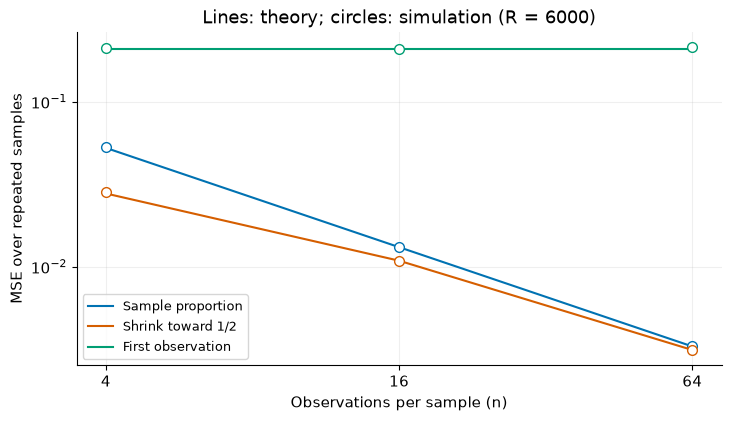

In [24]:
fig, ax = plt.subplots(figsize=(7.2, 4.1), layout="constrained")
# 每种估计器用同一颜色：线是理论 MSE，空心圆是重复实验估计。
for label, color in zip(simulation_mse, [blue, orange, green]):
    ax.loglog(sample_sizes, theory_mse[label], color=color, label=label)
    ax.loglog(
        sample_sizes,
        simulation_mse[label],
        "o",
        color=color,
        markerfacecolor="white",
        markersize=7,
    )
ax.set(
    xlabel="Observations per sample (n)",
    ylabel="MSE over repeated samples",
    title="Lines: theory; circles: simulation (R = 6000)",
)
# 仅标出实际比较过的样本量，避免把中间刻度误读为额外实验。
ax.set_xticks(sample_sizes, labels=[str(size) for size in sample_sizes])
ax.minorticks_off()
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
# 本次前两种估计器的 MSE 随 n 增大下降，只用首个观测的曲线保持约 0.21；模拟点贴近理论线。
plt.show()
# 比较趋势也要看目标参数与抽样假设；改成 p 接近边界时，两条前者曲线的排序可能改变。

## 本章小结

参数描述总体，估计量是随机样本的计算规则，估计值是代入一份数据后的结果。偏差、方差和 MSE 都对重复抽样定义；一致性另外讨论样本量趋于无穷时的行为，无偏并不等于一致，也不一定有最小 MSE。

似然固定数据而改变参数，对数似然把乘积变为求和。MLE 必须在给定参数空间内求最大值，边界、解的存在性和模型假设都要检查。正态同方差独立误差下，最小二乘对应系数的 MLE；方差 MLE 则一般有有限样本偏差。

理解自查：一份数据的估计值接近真值、一个估计量无偏、似然达到最大，这三件事分别能够说明什么，又不能说明什么？

## 练习

（1）对 $x=(0,1,0,1,1,0,0,1)$ 计算样本比例和收缩估计值。再把最后一个 1 改成 0，比较变化。为什么仅凭这两份样本不能判断某条规则是否无偏？请写出无偏定义里的期望针对什么对象。

In [25]:
exercise_data = np.array([0, 1, 0, 1, 1, 0, 0, 1])

# 计算两条规则的估计值，再用副本改变最后一项。
# 区分当前估计值的变化与跨所有可能样本的期望。

（2）改变独立性条件：先生成 20 个独立 Bernoulli$(0.3)$ 观测，再把每个值复制一次，得到长度为 40 的数组。推导这个数组均值的方差，并与 40 个独立观测的均值方差比较。重复模拟检查，解释为什么“数组长度翻倍”不一定让估计更精确。

In [26]:
exercise_rng = np.random.default_rng(202620)
exercise_repetitions = 4000
exercise_independent_count = 20

# 按行生成独立原始样本，再用 np.repeat(..., 2, axis=1) 复制每项。
# 先化简复制后均值与原均值的关系，再核对理论方差和经验方差。

（3）记录为 6 次全成功，但参数空间改为 $\Theta=[0,0.6]$。写出似然并求 MLE；再将参数空间改为 $(0,0.6)$，判断 MLE 是否存在。画图或比较候选参数只能辅助判断，答案还须说明单调性与端点是否属于参数空间。

In [27]:
exercise_successes = np.ones(6, dtype=int)
exercise_candidates = np.array([0.3, 0.5, 0.59, 0.6])

# 计算似然，分别标明候选参数是否属于两个参数空间。
# 说明最大值和只能逼近的上确界之间的区别。

（4）正态模型中，若均值 $\mu_0$ 已知且正确，只估计方差 $v>0$，重新推导 MLE。用 $x=(1.1,1.5,1.8,2.0)$、$\mu_0=1.5$ 计算它，再由 $E[(X_i-\mu_0)^2]$ 判断此时是否应除以 $n-1$。若给定的 $\mu_0$ 不是实际均值，期望又会多出哪一项？

In [28]:
exercise_normal_data = np.array([1.1, 1.5, 1.8, 2.0])
exercise_known_mean = 1.5

# 均值已知时，围绕已知均值而非样本均值计算离差平方和。
# 用期望展开解释无偏性，并讨论均值指定错误带来的影响。

## 练习提示与解析

以下对应练习（3）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：最大似然估计必须属于给定参数空间。

提示 2：全成功样本的似然在合法非负参数范围内随参数增大；检查最大端点是否被包含。

### 练习（3）参考解析

以 p 表示成功概率，六次独立全成功的似然为 $L(p)=p^6$。在 $[0,0.6]$ 上，它的最大值在 $\widehat p=0.6$ 取得。

在 $(0,0.6)$ 上，对任意候选 p，总能找到更大的合法参数使似然更大。似然的上确界为 $0.6^6$，却没有参数能在该空间内达到它，因此 MLE 不存在。把 0.599999 当作近似优化结果可以，但不能把它说成数学上的最大点。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| Deep Learning 作者网站 | Ian Goodfellow、Yoshua Bengio、Aaron Courville，[第 5 章 Machine Learning Basics](https://www.deeplearningbook.org/contents/ml.html)，§5.4.1–5.4.4、式 (5.19)–(5.54)：点估计、频率学派参数、偏差、标准误、方差估计与 MSE；§5.4.5、式 (5.55)：依概率一致性及仅用首个观测的反例；§5.5、式 (5.56)–(5.58)：似然乘积、对数似然与下溢。 |
| Hyebin Song / Penn State STAT 415 | [Point Estimation 原讲义](https://hsong1.github.io/teachings/psu-sp21-stat415/2_Point%20Estimation.html)，Introduction to Point Estimation 下 The bias and mean squared error of point estimators：偏差定义与 MSE 分解；Properties of Point Estimators 下 Large sample (asymptotic) properties：一致性定义及 MSE 趋零的充分条件；Maximum Likelihood Estimation 的 Bernoulli 例：闭参数空间的全成功、全失败边界。 |
| Stanford CS109 | Lisa Yan、Jerry Cain，[Lecture Notes 20: Maximum Likelihood Estimation](https://web.stanford.edu/class/archive/cs/cs109/cs109.1212/lectureNotes/LN20_parameters_mle.pdf)，2020，PDF 第 1–3 页 §1–2：参数、独立抽样与似然定义；第 3–4 页 §3.1：Bernoulli MLE；第 5 页 §3.4：正态均值和方差 MLE。 |
| MIT OpenCourseWare | Jeremy Orloff、Jonathan Bloom，[18.05 Statistics Reading](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_statistics.pdf)，2022，PDF 第 6 页 Class 10 Definition/Notes：似然与参数条件概率的区别；第 8–11 页 §3.2、§4：连续密度似然及正态模型；Philippe Rigollet，[18.650 Maximum Likelihood Estimation](https://ocw.mit.edu/courses/18-650-statistics-for-applications-fall-2016/36624c2682b346b07cab3da416b752a7_MIT18_650F16_Maximum_LE.pdf)，2016，PDF 第 16–22 页：离散与连续似然、参数空间及 MLE 存在性限定。 |
| Carnegie Mellon Statistics | Cosma Shalizi，[Simulation for Inference I](https://stat.cmu.edu/~cshalizi/dst/18/lectures/18/lecture-18.html)，2018，The Sampling Distribution Is the Source of All Knowledge、Measures of Uncertainty、In our last episode：抽样分布、标准误与重复模拟；Siva Balakrishnan，[Lecture 15](https://www.stat.cmu.edu/~siva/teaching/700/lec15.pdf)，2016，§15.3，PDF 第 3–4 页：高斯误差下最小二乘与 MLE、共同方差的 MLE。 |
| SciPy | [bernoulli](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bernoulli.html) 与 [binom](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html)，Methods、Notes：支持集、参数、pmf 与 logpmf；[norm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html)，Parameters/Methods、Notes：loc、scale、pdf 与 logpdf，scale 指标准差。 |
| NumPy | 2.5 文档：[Generator.binomial](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.binomial.html)，n、p、size：局部生成器的 Bernoulli/二项抽样；[var](https://numpy.org/doc/stable/reference/generated/numpy.var.html)，ddof 与 Notes：分母及 Bessel 修正；[lstsq](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html)，最小二乘解与返回秩。 |
| Matplotlib | [Axes.bar](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html)，x、height、width：离散概率柱形图；[Axes.loglog](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.loglog.html)，双对数坐标及非正数边界：理论和模拟误差曲线；[Axes.minorticks_off](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.minorticks_off.html)：关闭次刻度以突出实际样本量。 |